# Edge IIoT - Exploratory Data Analysis (EDA)

In [13]:
%load_ext autoreload
%autoreload 2

import pandas as pd
from src.config import DATASETS

# Seleccionamos el dataset a analizar
dataset_name = "edge_iiot"
config = DATASETS[dataset_name]

print("\n--- Dataset Information ---")
print(f"Name: {dataset_name.upper()}")
print(f"Path: {config['raw_path']}\n")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

--- Dataset Information ---
Name: EDGE_IIOT
Path: /home/uo294319/ML-NIDS-IIoT/data/raw/edge_iiot



## Selected dataset for Machine Learning (ML)

### Loading

In [14]:
csv_path = config['raw_path'] / "Edge-IIoTset dataset" / "Selected dataset for ML and DL" / "ML-EdgeIIoT-dataset.csv"
print(f"CSV Path: {csv_path}\n")

print("Loading dataset... (This may take a while)")
df_ml = pd.read_csv(csv_path, low_memory=False)

print(f"\nDataset loaded with shape: {df_ml.shape}")

CSV Path: /home/uo294319/ML-NIDS-IIoT/data/raw/edge_iiot/Edge-IIoTset dataset/Selected dataset for ML and DL/ML-EdgeIIoT-dataset.csv

Loading dataset... (This may take a while)

Dataset loaded with shape: (157800, 63)


### Types & Null values

In [15]:
quality_summary = pd.DataFrame({
    'Type': df_ml.dtypes,
    'Null': df_ml.isnull().sum(),
    '% Null': ((df_ml.isnull().sum() / len(df_ml)) * 100).map("{:.2f}%".format)
})

display(quality_summary)

,Type,Null,% Null
frame.time,str,0,0.00%
ip.src_host,str,0,0.00%
ip.dst_host,str,0,0.00%
arp.dst.proto_ipv4,str,0,0.00%
arp.opcode,float64,0,0.00%
...,...,...,...
mbtcp.len,float64,0,0.00%
mbtcp.trans_id,float64,0,0.00%
mbtcp.unit_id,float64,0,0.00%
Attack_label,int64,0,0.00%


### Target label (Attack type) distribution

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_label_distribution(df_data, label_col):

    conteo = df_data[label_col].value_counts()
    labels = conteo.index
    sizes = conteo.values

    palette_colors = sns.color_palette("viridis", len(labels))
    color_map = dict(zip(labels, palette_colors))

    explode = [0.05] * len(labels)

    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

    # --- Barplot ---
    sns.countplot(y=label_col,
                  data=df_data,
                  ax=ax1,
                  order=labels,
                  hue=label_col,
                  palette=color_map,
                  legend=False)

    ax1.set_title(f"Count of each {label_col}")
    ax1.set_xlabel("Count")
    ax1.set_ylabel(label_col)

    # --- Donut ---
    pie_colors = [color_map[label] for label in labels]

    ax2.pie(sizes,
            explode=explode,
            labels=labels,
            autopct='%1.1f%%',
            startangle=60,
            pctdistance=0.85,
            colors=pie_colors)

    center_circle = plt.Circle((0,0), 0.70, fc='white')
    ax2.add_artist(center_circle)

    ax2.set_title(f"Percentage of each {label_col}")

    plt.tight_layout()
    plt.show()

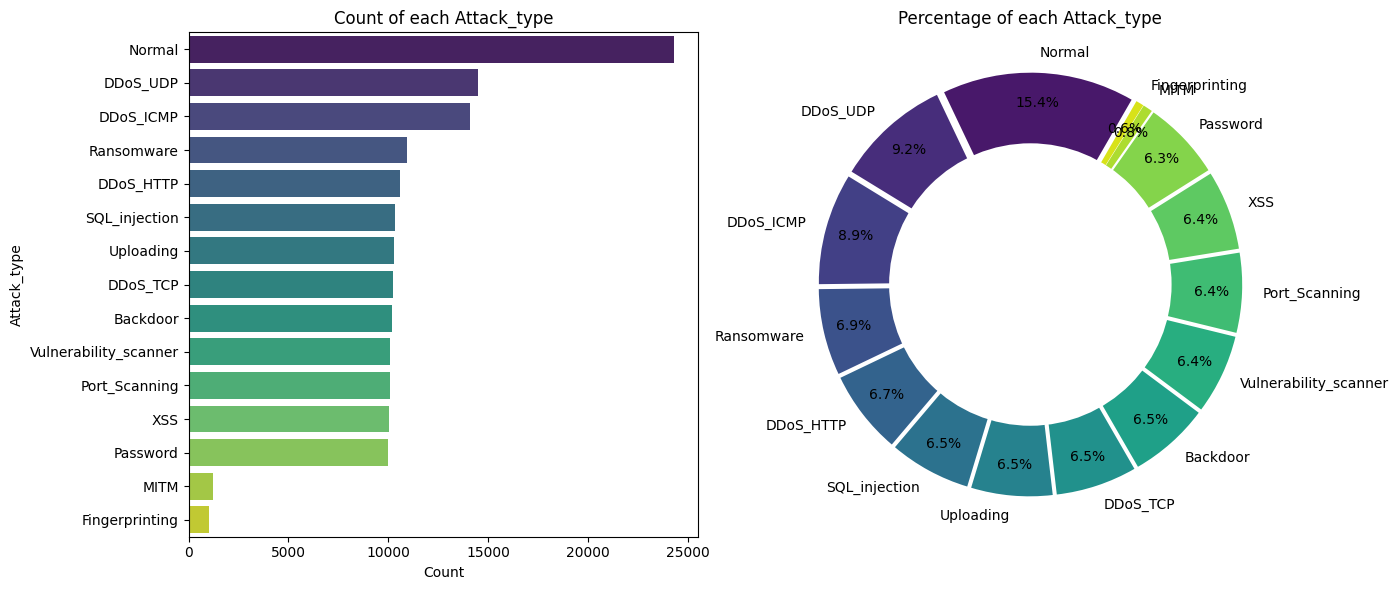

In [17]:
label_col = "Attack_type"
plot_label_distribution(df_ml, label_col)

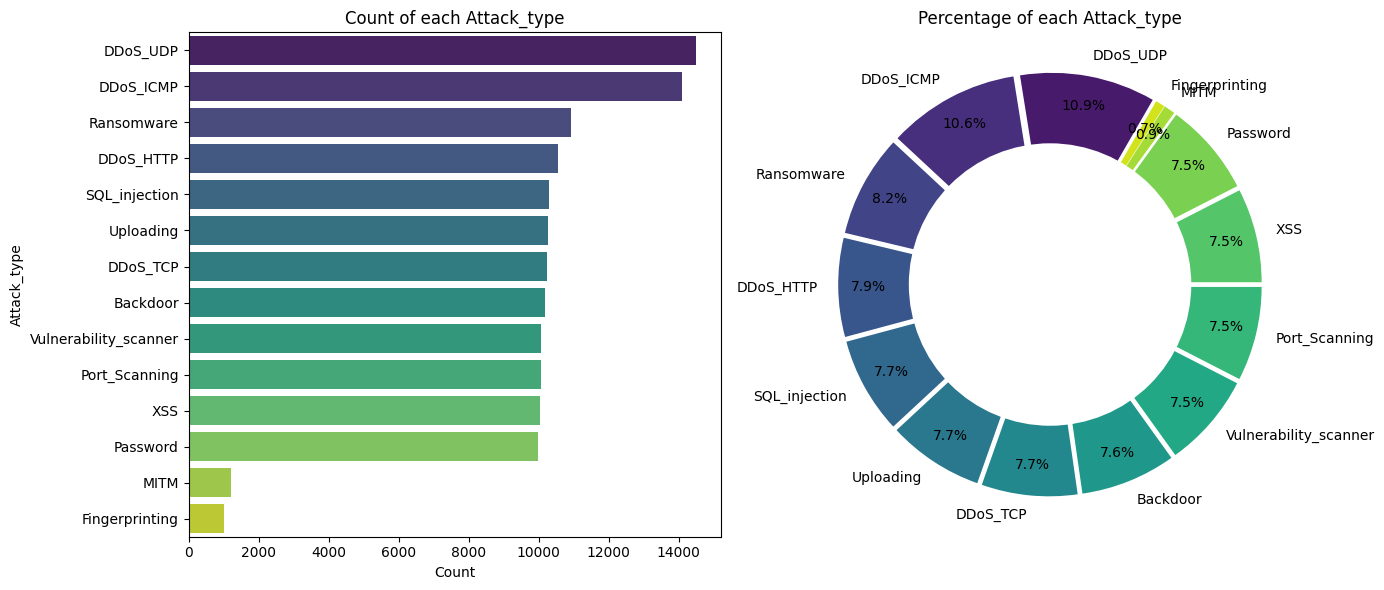

In [18]:
df_no_normal = df_ml[df_ml[label_col] != 'Normal']
plot_label_distribution(df_no_normal, label_col)

### Correlation Matrix

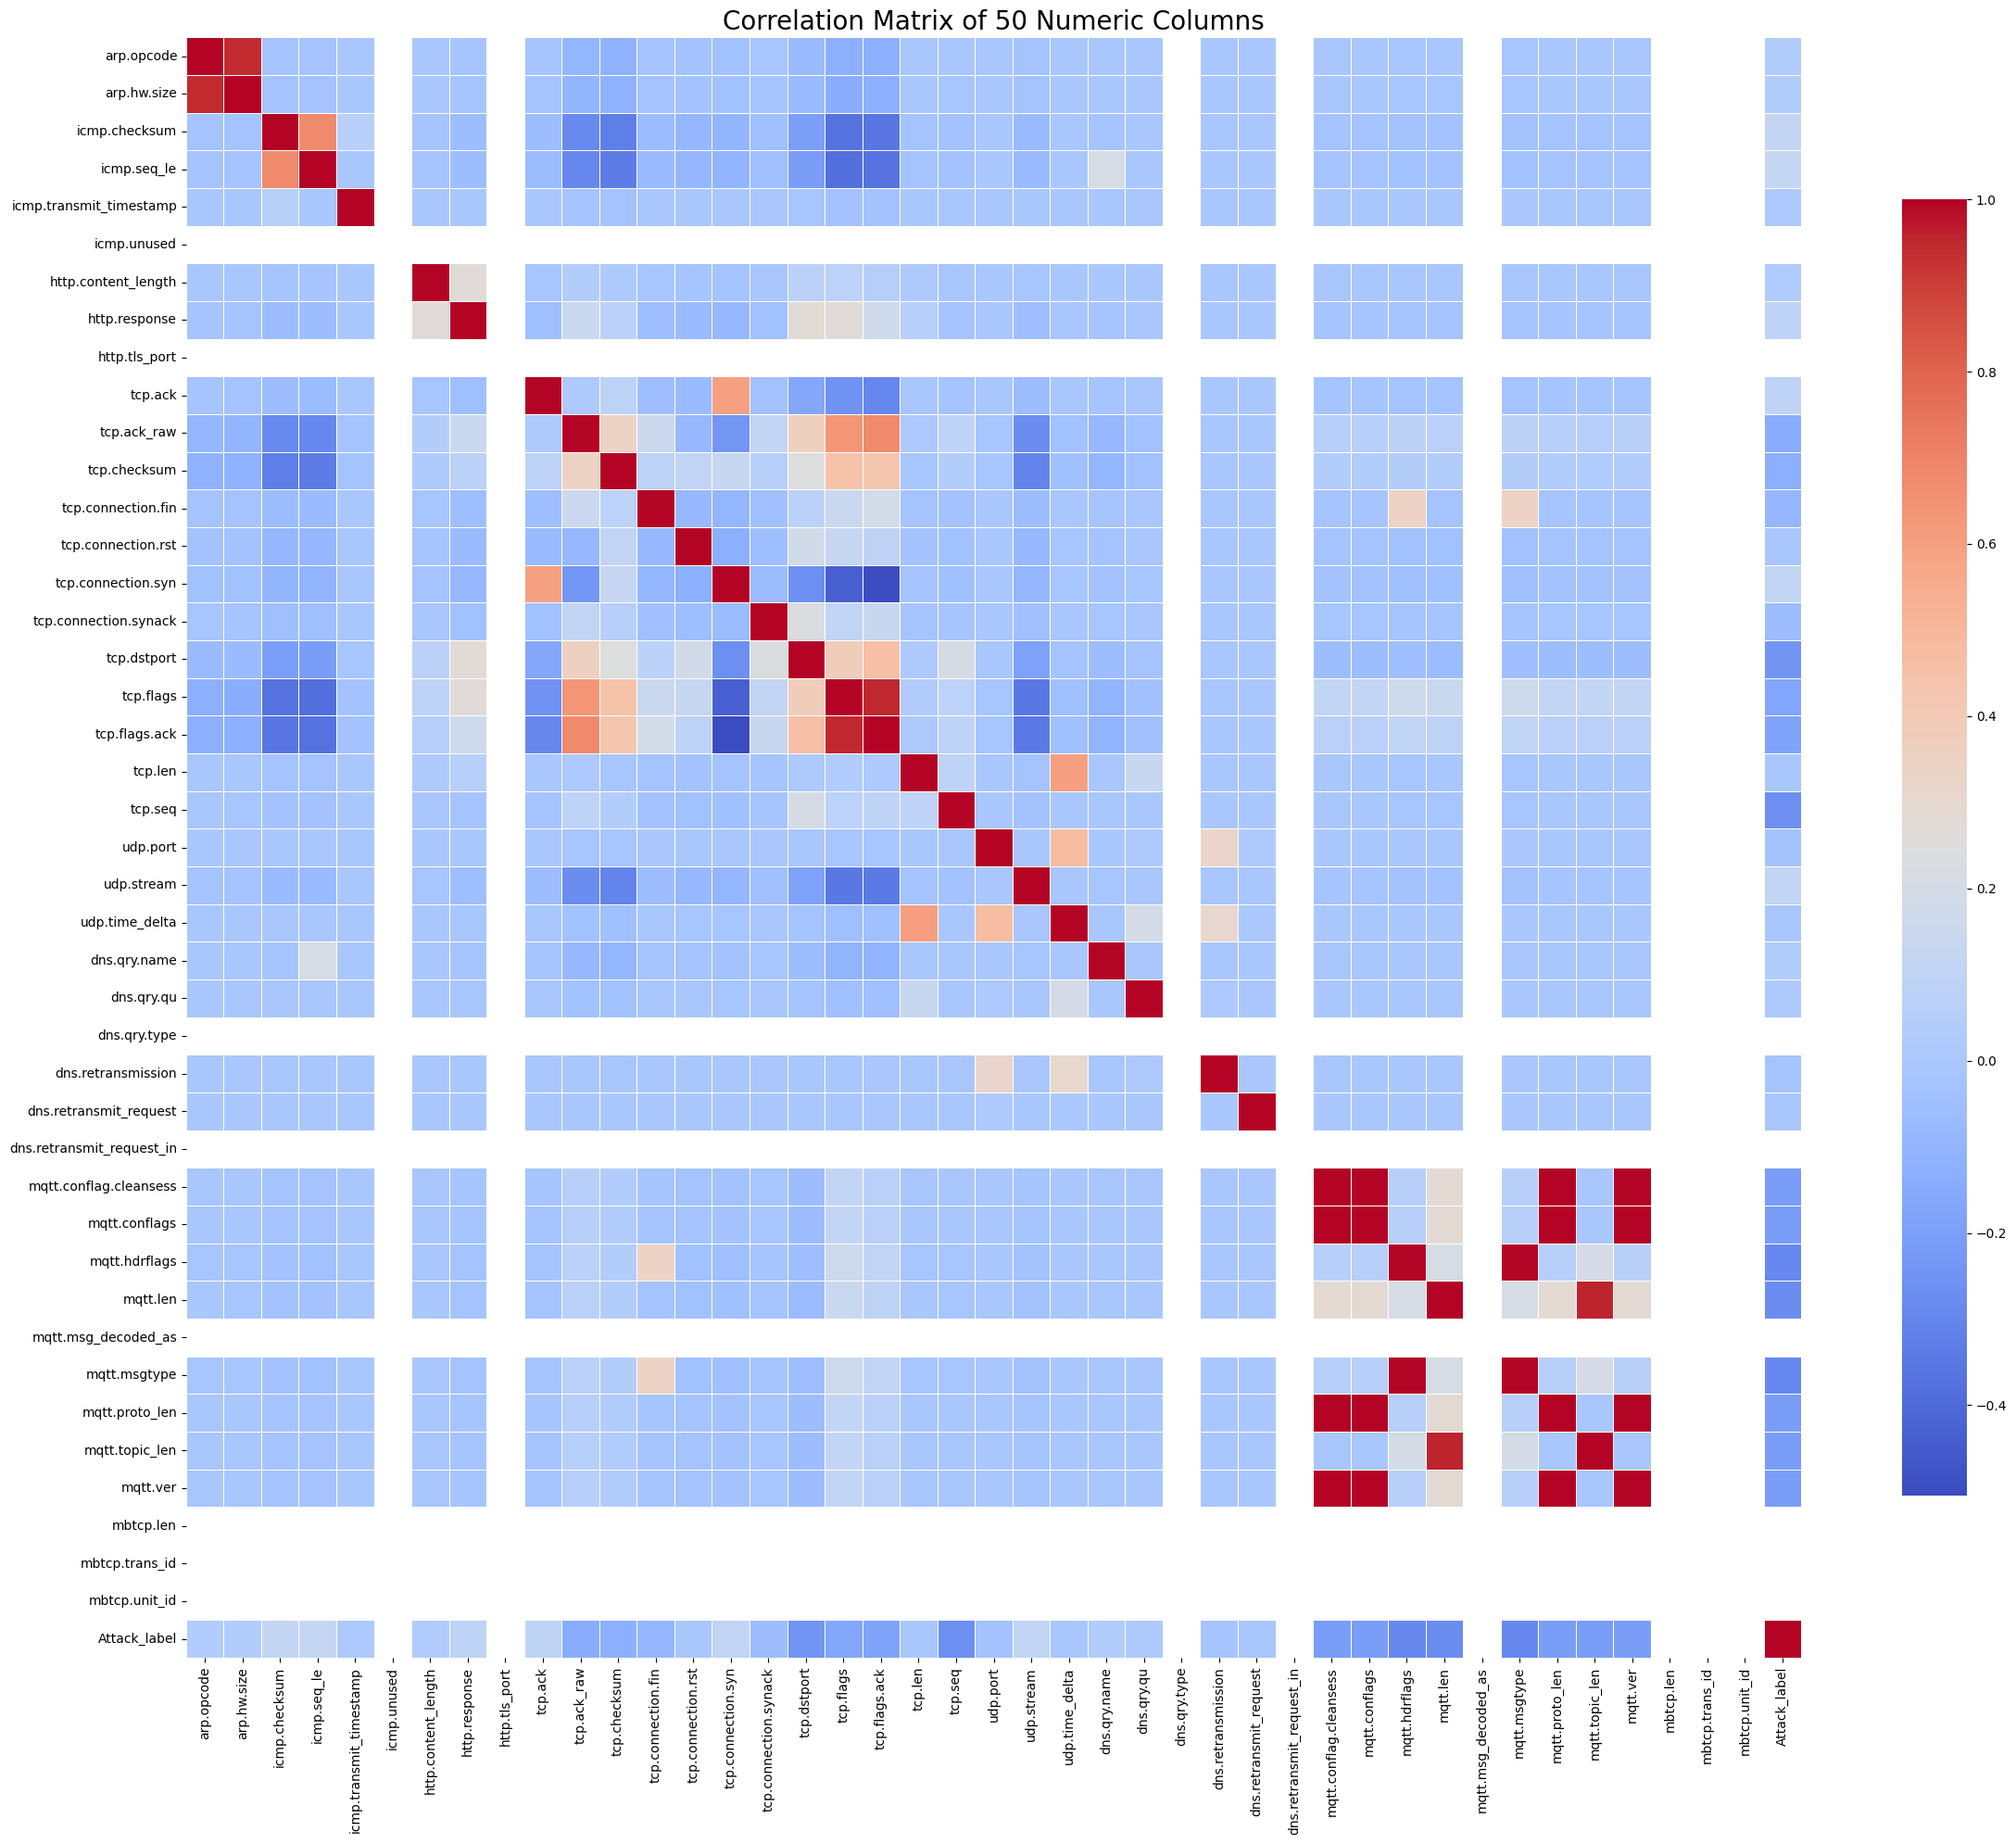

In [19]:
df_numeric = df_ml.select_dtypes(include=['int64', 'float64']) # Only the numeric columns
corr_matrix = df_numeric.corr()

plt.figure(figsize=(24, 20))
sns.heatmap(corr_matrix, 
            annot=False,
            cmap='coolwarm',
            linewidths=0.5,
            cbar_kws={"shrink": .8})

plt.title("Correlation Matrix of 50 Numeric Columns", fontsize=20)
plt.tight_layout()
plt.show()

## Selected dataset for Deep Learning (DL)

### Loading

In [20]:
csv_path = config['raw_path'] / "Edge-IIoTset dataset" / "Selected dataset for ML and DL" / "DNN-EdgeIIoT-dataset.csv"
print(f"CSV Path: {csv_path}\n")

print("Loading dataset... (This may take a while)")
df_dl = pd.read_csv(csv_path, low_memory=False)

print(f"\nDataset loaded with shape: {df_dl.shape}")

CSV Path: /home/uo294319/ML-NIDS-IIoT/data/raw/edge_iiot/Edge-IIoTset dataset/Selected dataset for ML and DL/DNN-EdgeIIoT-dataset.csv

Loading dataset... (This may take a while)

Dataset loaded with shape: (2219201, 63)


### Types & Null values

In [21]:
quality_summary = pd.DataFrame({
    'Type': df_dl.dtypes,
    'Null': df_dl.isnull().sum(),
    '% Null': ((df_dl.isnull().sum() / len(df_dl)) * 100).map("{:.2f}%".format)
})

display(quality_summary)

,Type,Null,% Null
frame.time,str,0,0.00%
ip.src_host,str,0,0.00%
ip.dst_host,str,0,0.00%
arp.dst.proto_ipv4,str,0,0.00%
arp.opcode,float64,0,0.00%
...,...,...,...
mbtcp.len,float64,0,0.00%
mbtcp.trans_id,float64,0,0.00%
mbtcp.unit_id,float64,0,0.00%
Attack_label,int64,0,0.00%


### Target label (Attack type) distribution


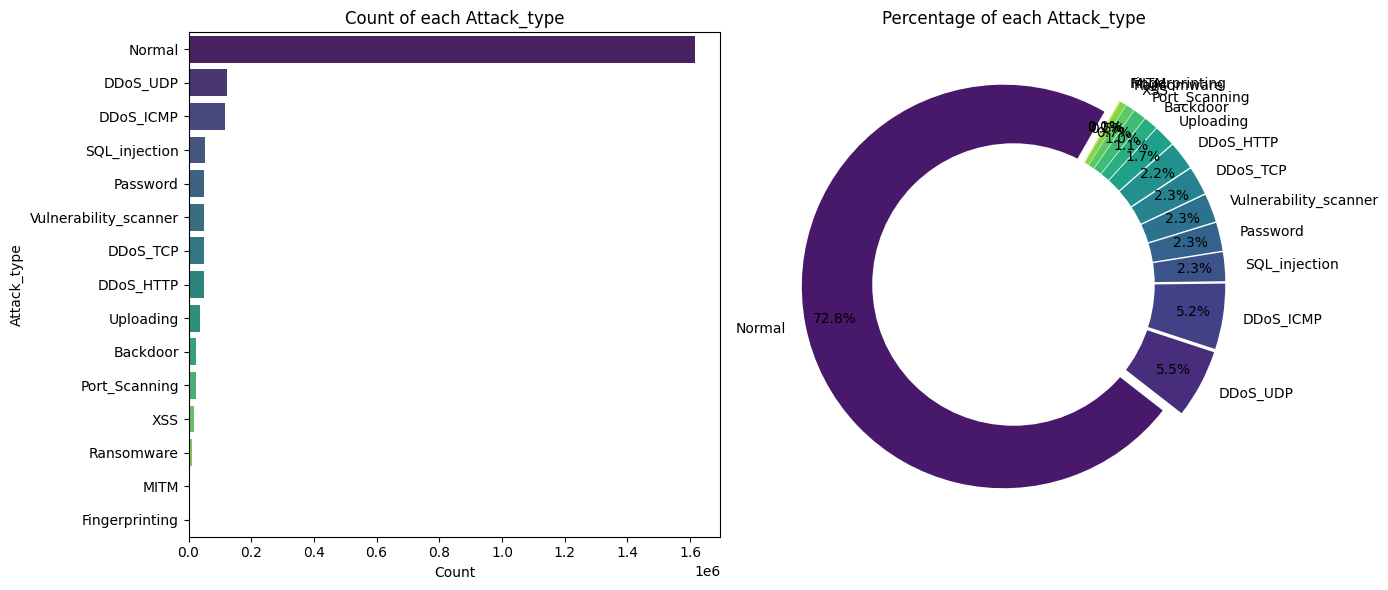

In [22]:
label_col = "Attack_type"
plot_label_distribution(df_dl, label_col)

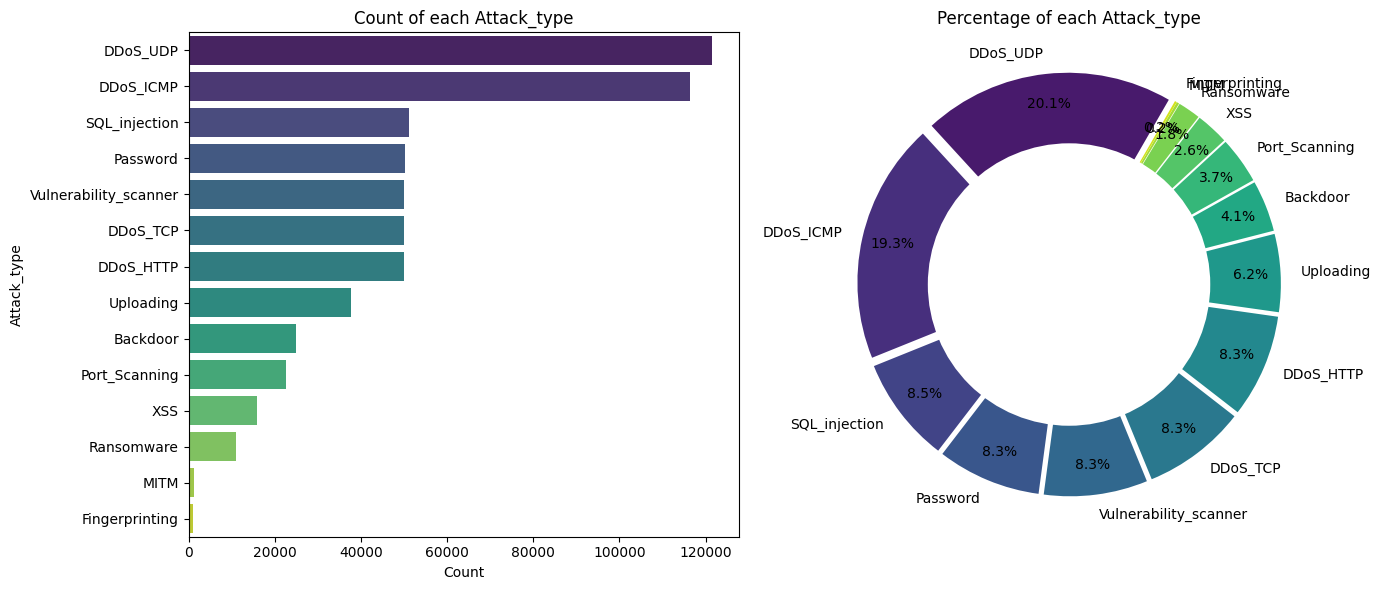

In [23]:
df_no_normal = df_dl[df_dl[label_col] != 'Normal']
plot_label_distribution(df_no_normal, label_col)

### Correlation Matrix

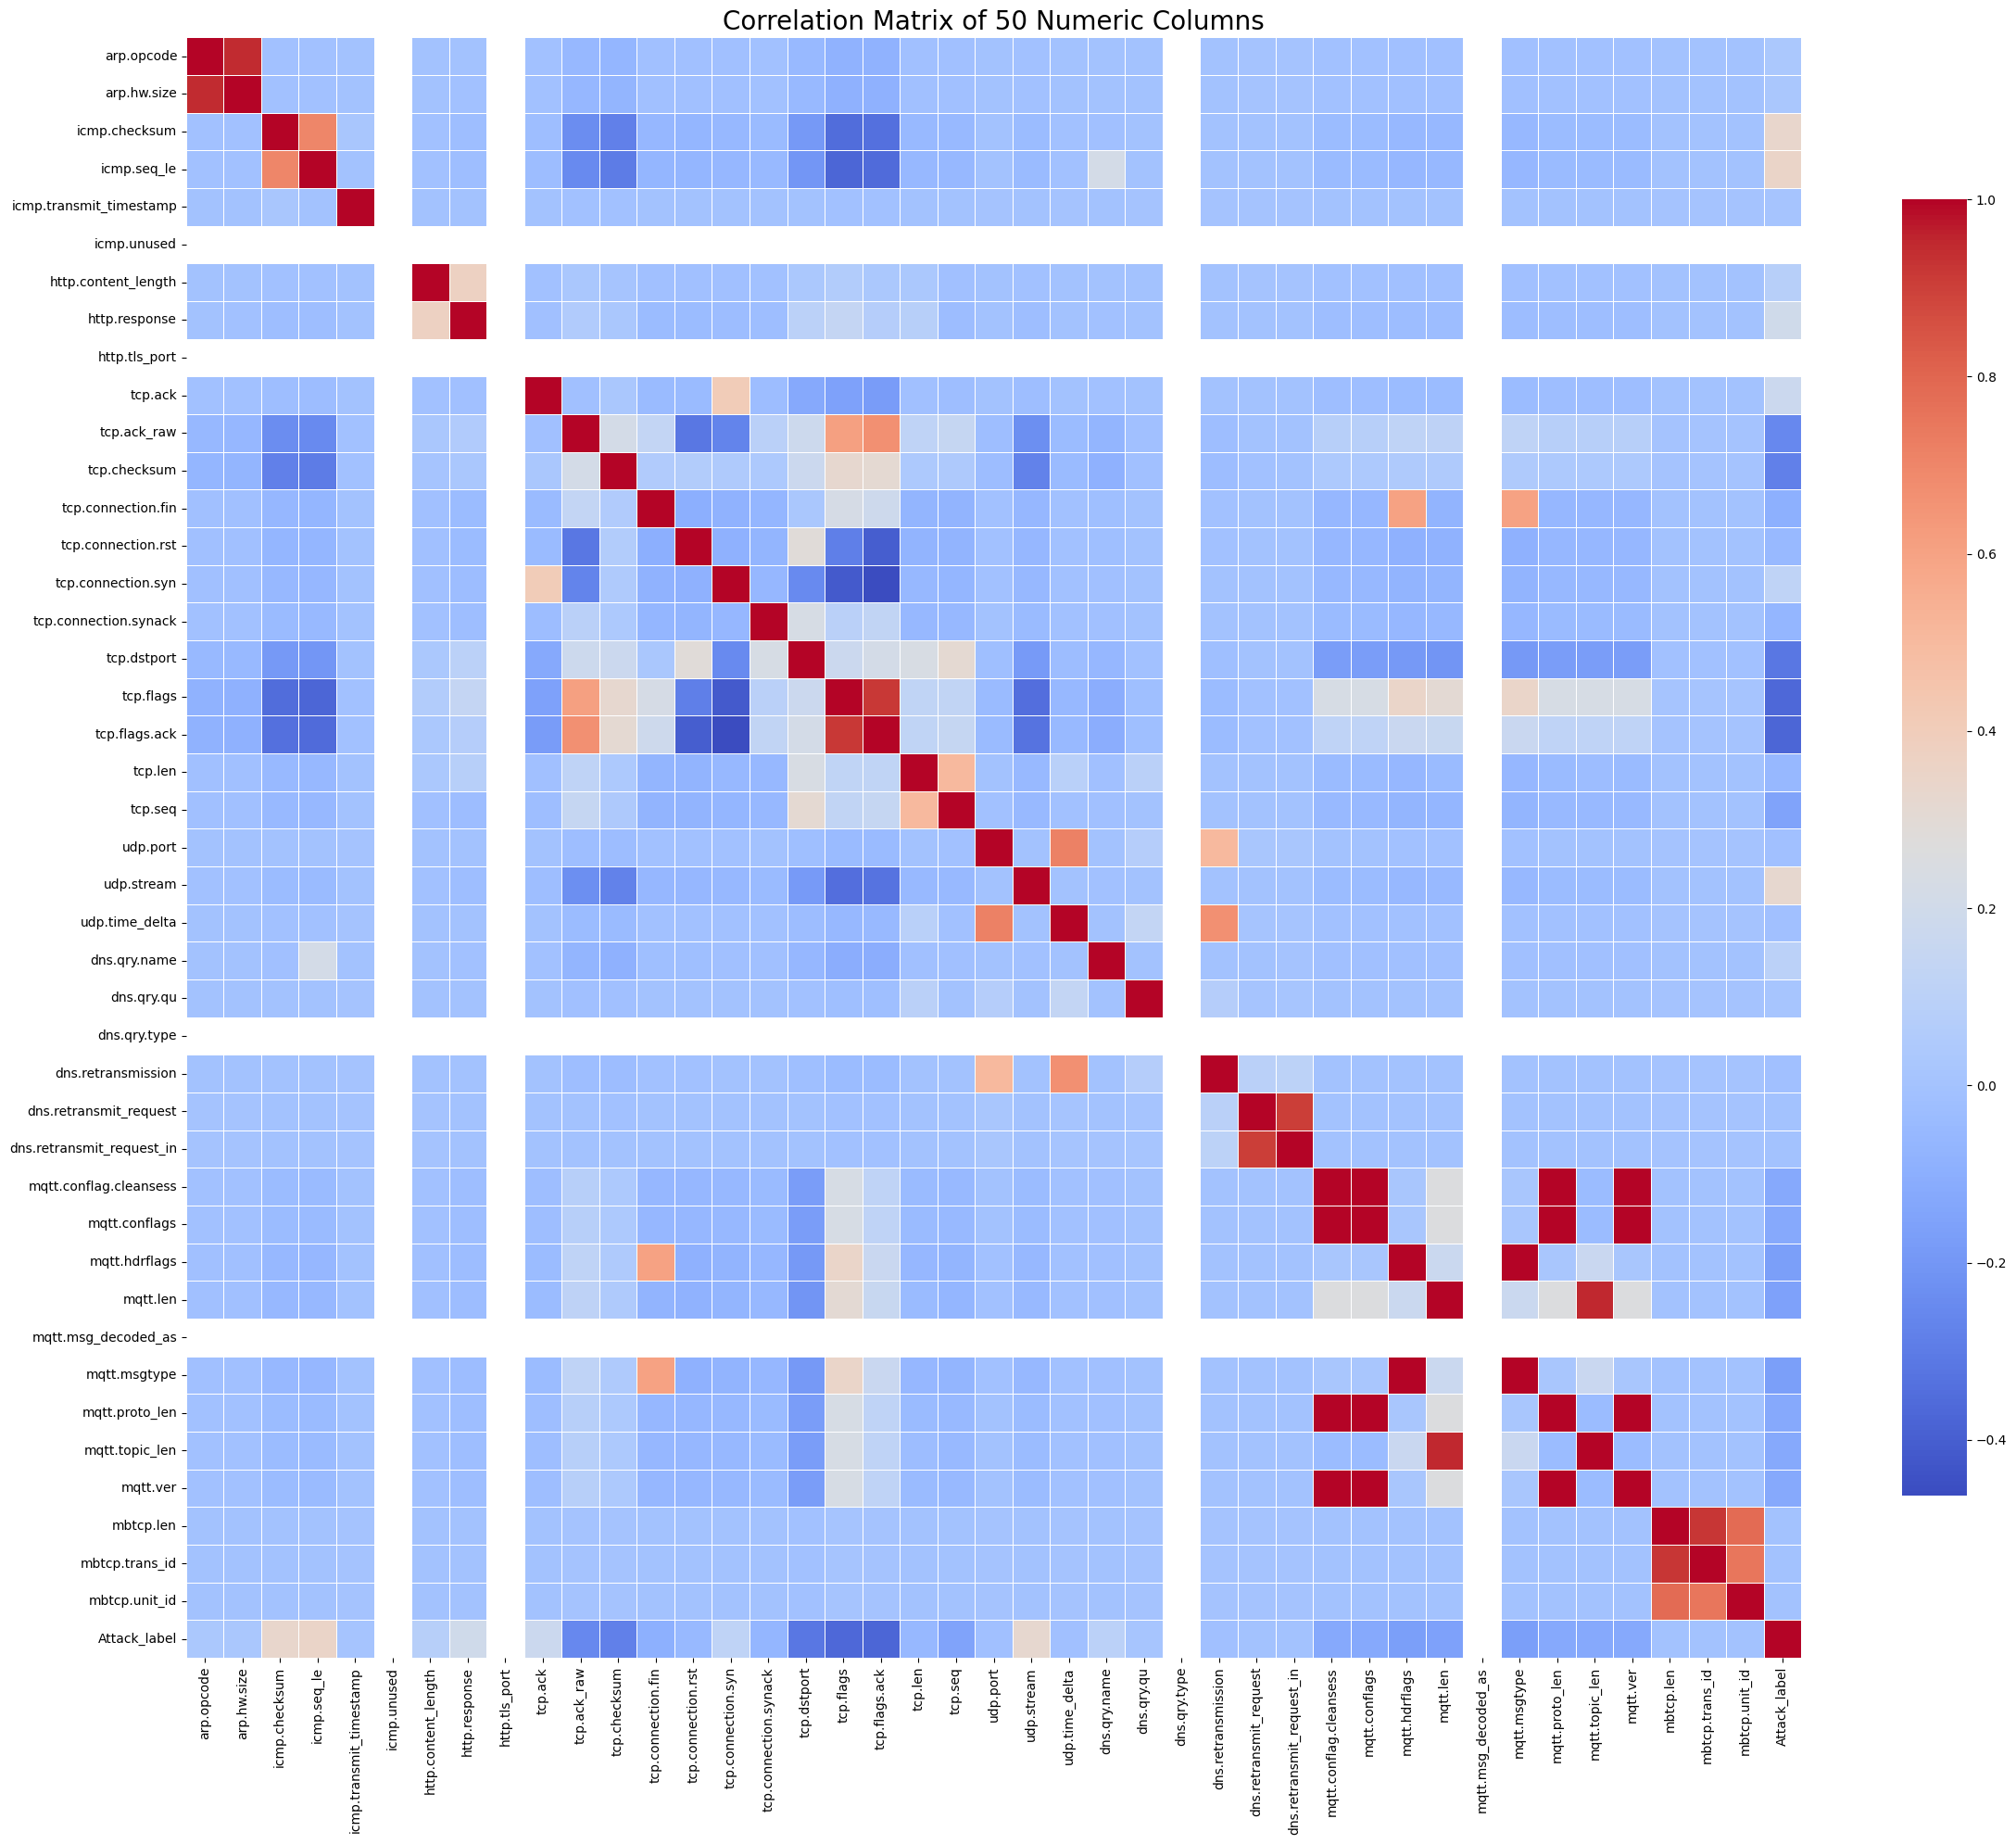

In [24]:
df_numeric = df_dl.select_dtypes(include=['int64', 'float64']) # Only the numeric columns
corr_matrix = df_numeric.corr()

plt.figure(figsize=(24, 20))
sns.heatmap(corr_matrix, 
            annot=False,
            cmap='coolwarm',
            linewidths=0.5,
            cbar_kws={"shrink": .8})

plt.title("Correlation Matrix of 50 Numeric Columns", fontsize=20)
plt.tight_layout()
plt.show()